# KIQ 2.3 — Customer Expectations in Digital Ordering

**BERTopic on SCOPUS abstracts**, n = 1,428 (2018–2026)

Course-aligned pipeline: **SBERT → UMAP → HDBSCAN → CountVectorizer → c-TF-IDF**

Reference: Grootendorst, M. (2022). *BERTopic: Neural topic modeling with a class-based TF-IDF procedure.* arXiv:2203.05794

## 1. Install BERTopic

In [ ]:
!pip install bertopic --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.2 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

## 3. Upload CSV

Run the cell below, then click **Choose Files** and select scopus_kiq23.csv.

Alternatively, drag-and-drop the file into the Files panel on the left sidebar.

In [ ]:
#from google.colab import files
#uploaded = files.upload()  # select scopus_kiq23.csv

## 4. Load & prepare data

Combine **Title + Abstract** as the document for embedding. Drop documents that are too short.

In [ ]:
df = pd.read_csv("/content/scopus_kiq23.csv")

print(f"Loaded {len(df)} papers")
print(f"Columns: {df.columns.tolist()[:10]}...")

# Drop rows missing both Title and Abstract
df = df.dropna(subset=["Title", "Abstract"], how="all").reset_index(drop=True)

# Combine Title + Abstract
df["doc"] = df["Title"].fillna("") + ". " + df["Abstract"].fillna("")

# Drop very short documents
df = df[df["doc"].str.len() > 50].reset_index(drop=True)

docs = df["doc"].tolist()
print(f"\nFinal corpus: {len(docs)} documents")

Loaded 1414 papers
Columns: ['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start']...

Final corpus: 1413 documents


## 5. Build the BERTopic pipeline

Modular stack per the course slides:

1. **Embeddings**: SBERT (all-MiniLM-L6-v2) — fast, English-optimized
2. **Dimensionality reduction**: UMAP
3. **Clustering**: HDBSCAN
4. **Tokenizer**: CountVectorizer (English stopwords + bigrams)
5. **Topic weighting**: c-TF-IDF (default in BERTopic)

In [ ]:
# Seed for reproducibility
np.random.seed(42)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=2,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 6. Fit the model

Takes ~3–5 min on Colab CPU; ~30 sec with GPU runtime.

In [11]:
topics, _ = topic_model.fit_transform(docs)

# Optional: collapse to a more interpretable number of topics
topic_model.reduce_topics(docs, nr_topics="auto")

2026-06-03 10:57:41,180 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

2026-06-03 11:00:33,112 - BERTopic - Embedding - Completed ✓
2026-06-03 11:00:33,114 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 11:00:38,931 - BERTopic - Dimensionality - Completed ✓
2026-06-03 11:00:38,933 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 11:00:39,022 - BERTopic - Cluster - Completed ✓
2026-06-03 11:00:39,023 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-03 11:00:40,111 - BERTopic - Representation - Completed ✓
2026-06-03 11:00:40,112 - BERTopic - Topic reduction - Reducing number of topics
2026-06-03 11:00:40,127 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 11:00:41,205 - BERTopic - Representation - Completed ✓
2026-06-03 11:00:41,213 - BERTopic - Topic reduction - Reduced number of topics from 17 to 17
2026-06-03 11:00:41,726 - BERTopic - Topic reduction - Reducing number of topics
2026-06-03 11:00:41,736 - BE

## 7. Topic overview

In [12]:
topic_info = topic_model.get_topic_info()
print(f"\nDiscovered {len(topic_info) - 1} topics (excluding outlier topic -1)\n")
topic_info.head(20)


Discovered 16 topics (excluding outlier topic -1)



,Topic,Count,Name,Representation,Representative_Docs
0,-1,455,-1_customer_study_service_hospitality,"[customer, study, service, hospitality, experi...",[Service quality gap models: trends and indust...
1,0,224,0_ai_hospitality_intelligence_tourism,"[ai, hospitality, intelligence, tourism, artif...",[Has AI Revolutionised Customer Experience in ...
2,1,109,1_robots_robot_service_service robots,"[robots, robot, service, service robots, human...",[Human–robot interaction attributes at the res...
3,2,87,2_sentiment_reviews_analysis_sentiment analysis,"[sentiment, reviews, analysis, sentiment analy...",[Sentiment Analysis of Hotel Reviews Using Lex...
4,3,79,3_brand_customer_csr_customers,"[brand, customer, csr, customers, study, value...",[The impact of corporate social responsibility...
5,4,56,4_metaverse_virtual_ar_tourism,"[metaverse, virtual, ar, tourism, reality, vr,...",[Metaverse customer journeys in tourism: build...
6,5,56,5_food_restaurant_study_consumers,"[food, restaurant, study, consumers, purchase,...","[What drives customer satisfaction, loyalty, a..."
7,6,53,6_experience_hospitality_research_customer,"[experience, hospitality, research, customer, ...",[Experience management in hospitality and tour...
8,7,50,7_hotel_customer_satisfaction_quality,"[hotel, customer, satisfaction, quality, servi...",[A multi-perspective approach of international...
9,8,45,8_green_environmental_practices_sustainability,"[green, environmental, practices, sustainabili...",[Consumers’ green purchase intention to visit ...


In [32]:
from google.colab import files

# Export topic info to CSV
topic_info.to_csv("kiq23_topic_info.csv", index=False)
files.download("kiq23_topic_info.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Top 10 terms per topic

In [16]:
print("=== Top 10 terms per topic ===\n")
for tid in topic_info["Topic"].tolist()[:15]:
    if tid == -1:
        continue
    terms = topic_model.get_topic(tid)
    term_list = ", ".join([t[0] for t in terms[:10]])
    print(f"Topic {tid:>2}  |  {term_list}")

=== Top 10 terms per topic ===

Topic  0  |  ai, hospitality, intelligence, tourism, artificial, artificial intelligence, customer, industry, smart, technologies
Topic  1  |  robots, robot, service, service robots, human, robotic, customer, hospitality, study, customers
Topic  2  |  sentiment, reviews, analysis, sentiment analysis, customer, learning, hotel, data, based, online
Topic  3  |  brand, customer, csr, customers, study, value, creation, loyalty, engagement, hospitality
Topic  4  |  metaverse, virtual, ar, tourism, reality, vr, hospitality, research, immersive, experience
Topic  5  |  food, restaurant, study, consumers, purchase, restaurants, quality, organic, service, intentions
Topic  6  |  experience, hospitality, research, customer, experiences, tourism, customer experience, cem, management, industry
Topic  7  |  hotel, customer, satisfaction, quality, service, hotels, study, customer satisfaction, reviews, service quality
Topic  8  |  green, environmental, practices, sust

## 9. Visualisations (course-endorsed)

- visualize_topics() — intertopic distance map (similar to LDAvis)
- visualize_barchart() — top terms per topic
- visualize_hierarchy() — dendrogram, justifies topic count

In [17]:
# 1. Intertopic distance map
fig_topics = topic_model.visualize_topics()
fig_topics.write_html("kiq23_intertopic_map.html")
fig_topics.show()

In [19]:
# 2. Top terms per topic
fig_bar = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
fig_bar.write_html("kiq23_topic_barchart.html")
fig_bar.show()

In [20]:
# 3. Hierarchy dendrogram
fig_hier = topic_model.visualize_hierarchy()
fig_hier.write_html("kiq23_topic_hierarchy.html")
fig_hier.show()

In [ ]:
# Download the HTMLs
files.download("kiq23_intertopic_map.html")
files.download("kiq23_topic_barchart.html")
files.download("kiq23_topic_hierarchy.html")

## 10. Topic prevalence over time (2018–2026)

Shows how topic emphasis shifts across the years — useful for identifying emerging vs. plateauing themes.

In [21]:
years = df["Year"].astype(int).tolist()

topics_over_time = topic_model.topics_over_time(
    docs,
    years,
    nr_bins=9
)

fig_time = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=8)
fig_time.write_html("kiq23_topics_over_time.html")
fig_time.show()

files.download("kiq23_topics_over_time.html")

9it [00:01,  6.10it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Document–topic assignments

In [22]:
df["topic"] = topics
df[["Title", "Year", "Source title", "topic"]].to_csv("kiq23_doc_topics.csv", index=False)
files.download("kiq23_doc_topics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Output files

| File | Content |
|---|---|
| kiq23_topic_info.csv | Topic summary table |
| kiq23_doc_topics.csv | Document → topic assignments |
| kiq23_intertopic_map.html | Intertopic distance map |
| kiq23_topic_barchart.html | Top terms per topic |
| kiq23_topic_hierarchy.html | Hierarchical clustering |
| kiq23_topics_over_time.html | Topic prevalence over time |

# decide to cluster using K-means in order to let data decide

In [23]:
import plotly.graph_objects as go
import numpy as np
from sklearn.cluster import KMeans
from collections import Counter

In [24]:
# Get BERTopic's actual layout
fig_orig = topic_model.visualize_topics()
trace = fig_orig.data[0]
xs = np.array(trace.x)
ys = np.array(trace.y)
sizes_orig = list(trace.marker.size)

topic_ids_in_order = (
    topic_model.get_topic_info()
    .query("Topic != -1")['Topic']
    .tolist()
)

# === KMeans on the actual 2D positions ===
coords = np.column_stack([xs, ys])
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(coords)
spatial_labels = kmeans.labels_     # array of 0/1 for each bubble

# === Map spatial clusters to semantic names ===
# The smaller cluster contains the operational topics (T13-15)
counts = Counter(spatial_labels)
big_cluster_id = max(counts, key=counts.get)
small_cluster_id = min(counts, key=counts.get)

cluster_to_name = {
    big_cluster_id:   'Experience Economy',
    small_cluster_id: 'Operational / Transactional',
}
color_map = {
    'Experience Economy':         '#003366',  # navy
    'Operational / Transactional':'#a31515',  # bright red
}

# === Build figure ===
fig_recolor = go.Figure()
for cluster_id, macro_name in cluster_to_name.items():
    idx = [i for i, lbl in enumerate(spatial_labels) if lbl == cluster_id]
    fig_recolor.add_trace(go.Scatter(
        x=xs[idx], y=ys[idx],
        mode='markers+text',
        marker=dict(
            size=[sizes_orig[i] for i in idx],
            color=color_map[macro_name],
            opacity=0.80,
            line=dict(width=2, color='white')
        ),
        text=[f"T{topic_ids_in_order[i]}" for i in idx],
        textposition='middle center',
        textfont=dict(color='white', size=11, family='Arial Black'),
        name=f"{macro_name} (n={len(idx)} topics)"
    ))

fig_recolor.update_layout(
    title=dict(text='Intertopic Distance Map — clusters from KMeans (k=2) on UMAP coords',
               x=0.5, font=dict(size=15)),
    plot_bgcolor='white',
    width=1200, height=800,
    xaxis=dict(title='D1', gridcolor='#e8e8e8'),
    yaxis=dict(title='D2', gridcolor='#e8e8e8'),
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)')
)
fig_recolor.write_html('kiq23_intertopic_kmeans.html')
fig_recolor.show()

# Print which topics fell where (for the report)
for cluster_id, macro_name in cluster_to_name.items():
    topics_in = [topic_ids_in_order[i] for i, lbl in enumerate(spatial_labels) if lbl == cluster_id]
    print(f"{macro_name}: topics {sorted(topics_in)}")

Experience Economy: topics [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12]
Operational / Transactional: topics [5, 13, 14, 15]


##

In [27]:
import matplotlib.pyplot as plt
from collections import Counter

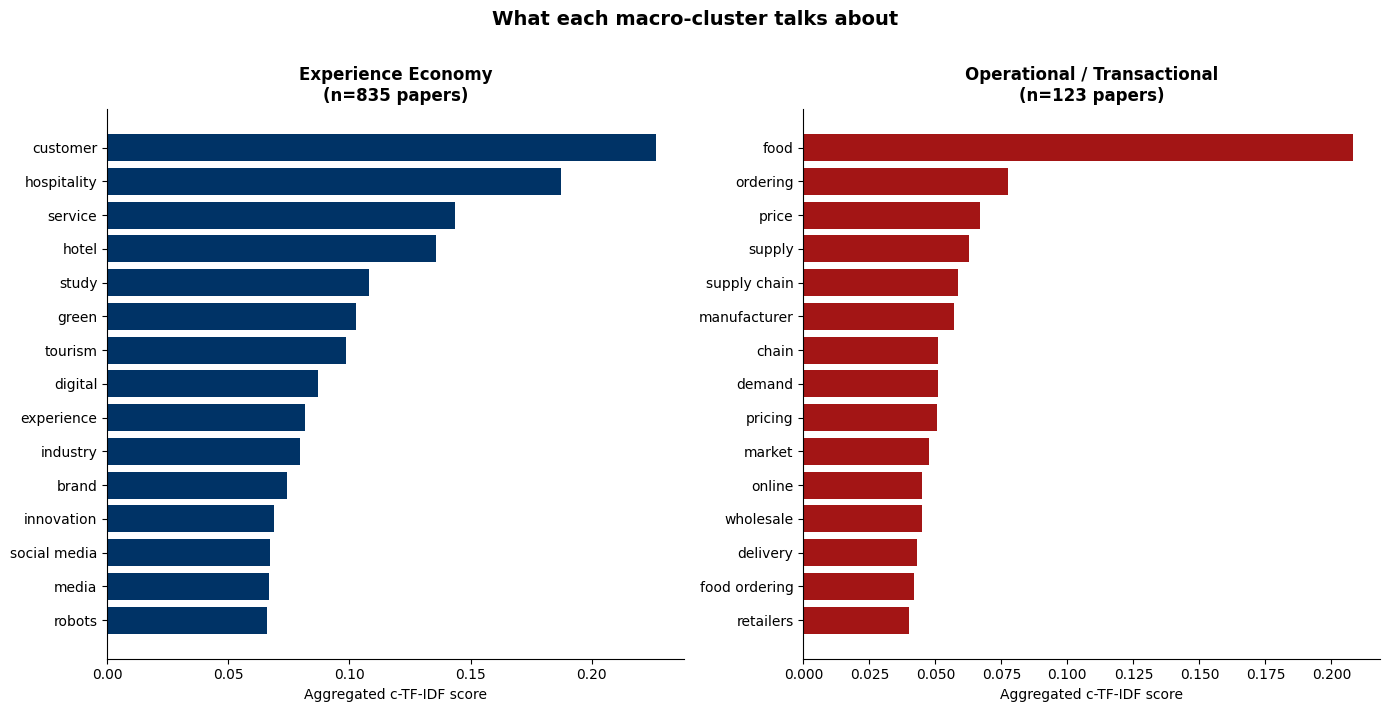

In [29]:
def get_macro_terms(topic_ids, top_n=15):
    all_terms = Counter()
    for tid in topic_ids:
        for term, score in topic_model.get_topic(tid)[:20]:
            all_terms[term] += score
    return all_terms.most_common(top_n)

exp_terms = get_macro_terms(experience_topics)
op_terms  = get_macro_terms(operational_topics)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (name, terms, color, n) in zip(axes, [
    ('Experience Economy', exp_terms, '#003366',
     sum(df['topic'].isin(experience_topics))),
    ('Operational / Transactional', op_terms, '#a31515',
     sum(df['topic'].isin(operational_topics)))
]):
    labels = [t[0] for t in reversed(terms)]
    values = [t[1] for t in reversed(terms)]
    ax.barh(labels, values, color=color)
    ax.set_title(f'{name}\n(n={n} papers)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Aggregated c-TF-IDF score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('What each macro-cluster talks about',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kiq23_macro_terms.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
files.download('kiq23_macro_terms.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

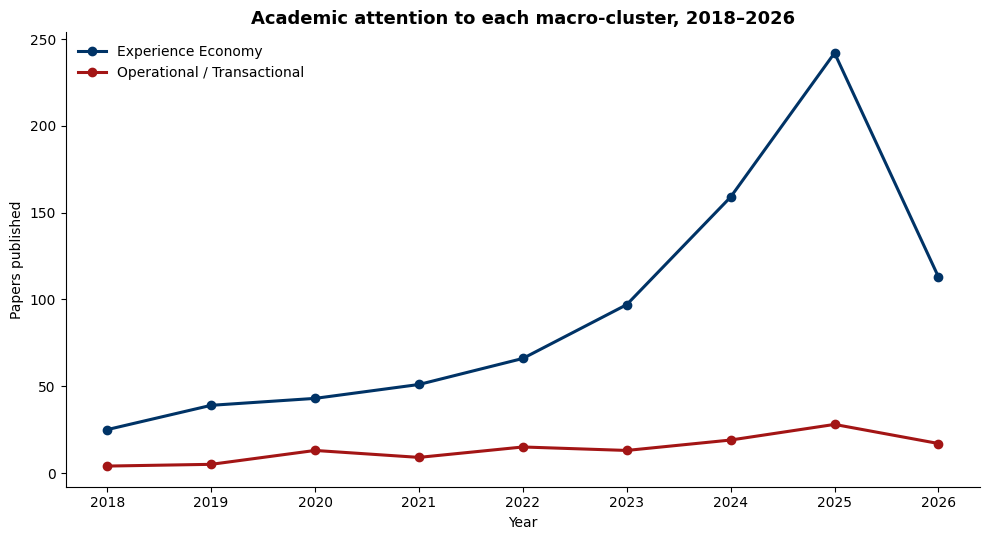

In [33]:
trend = (df[df['macro_cluster'] != 'Outliers']
         .groupby(['Year', 'macro_cluster']).size()
         .reset_index(name='count'))

fig, ax = plt.subplots(figsize=(10, 5.5))
for cluster in ['Experience Economy', 'Operational / Transactional']:
    sub = trend[trend['macro_cluster'] == cluster]
    ax.plot(sub['Year'], sub['count'], marker='o', linewidth=2.2,
            label=cluster, color=color_map[cluster])
ax.set_title('Academic attention to each macro-cluster, 2018–2026',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Papers published')
ax.legend(loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('kiq23_macro_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
files.download('kiq23_macro_trend.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
# Macro-cluster PNGs (one by one)
files.download('kiq23_macro_volumes.png')

In [ ]:
files.download('kiq23_macro_terms.png')

In [ ]:
files.download('kiq23_macro_trend.png')

In [ ]:
# Hierarchy dendrogram (if not already saved)
fig_hier = topic_model.visualize_hierarchy()
fig_hier.write_html("kiq23_topic_hierarchy.html")
fig_hier.show()
files.download('kiq23_topic_hierarchy.html')